<a href="https://colab.research.google.com/github/viictorsauraa/AprendizajeporRefuerzo_SauraCarmonaCortesGrupo7/blob/main/bandit_experiment_Greedy_con_inicializacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estudio comparativo de algoritmos en un problema de k-armed bandit

*Description:* El experimento compara el rendimiento de algoritmos epsilon-greedy en un problema de k-armed bandit.
Se generan gráficas de recompensas promedio para cada algoritmo.

    Author: Luis Daniel Hernández Molinero
    Email: ldaniel@um.es
    Date: 2025/01/29

This software is licensed under the GNU General Public License v3.0 (GPL-3.0),
with the additional restriction that it may not be used for commercial purposes.

For more details about GPL-3.0: https://www.gnu.org/licenses/gpl-3.0.html



## Preparación del entorno


In [1]:
#@title Copiar el repositorio.
import os

if 'google.colab' in str(get_ipython()):
    if not os.path.exists('/content/AprendizajeporRefuerzo_SauraCarmonaCortesGrupo7'):
        !git clone https://github.com/viictorsauraa/AprendizajeporRefuerzo_SauraCarmonaCortesGrupo7.git
    %cd /content/AprendizajeporRefuerzo_SauraCarmonaCortesGrupo7/k_brazos


--2026-02-25 15:56:28--  https://univmurcia-my.sharepoint.com/:u:/g/personal/victor_sauram_um_es/IQDbuIsISZ-fSa4fYiajelU0AWpQzsdov1VM9fevimYgjw8?download=1
Resolving univmurcia-my.sharepoint.com (univmurcia-my.sharepoint.com)... 13.107.136.10, 13.107.138.10, 2620:1ec:8f8::10, ...
Connecting to univmurcia-my.sharepoint.com (univmurcia-my.sharepoint.com)|13.107.136.10|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: /personal/victor_sauram_um_es/Documents/(EML)%20Extensiones%20de%20Machine%20Learning/eml_k_bandit.zip?ga=1 [following]
--2026-02-25 15:56:29--  https://univmurcia-my.sharepoint.com/personal/victor_sauram_um_es/Documents/(EML)%20Extensiones%20de%20Machine%20Learning/eml_k_bandit.zip?ga=1
Reusing existing connection to univmurcia-my.sharepoint.com:443.
HTTP request sent, awaiting response... 200 OK
Length: 43014 (42K) [application/x-zip-compressed]
Saving to: ‘eml_k_bandit.zip’

eml_k_bandit.zip    100%[===================>]  42.01K  --.-KB/s    i

In [2]:
#@title Importamos todas las clases y funciones

import sys

# Añadir los directorio fuentes al path de Python
sys.path.insert(0, 'src')



import numpy as np
from typing import List

from algorithms import Algorithm, EpsilonGreedyinitialization
from arms import ArmNormal, Bandit
from plotting import (
    plot_average_rewards,
    plot_optimal_selections,
    plot_regret,
    plot_arm_statistics
)

['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython', '/content/eml_k_bandit']


## Experimento

Cada algoritmo se ejecuta en un problema de k-armed bandit durante un número de pasos de tiempo y ejecuciones determinado.
Se comparan los resultados de los algoritmos en términos de recompensa promedio.

Por ejemplo. Dado un bandido de k-brazos, se ejecutan dos algoritmos epsilon-greedy con diferentes valores de epsilon. Se estudia la evolución de cada política  en un número de pasos, por ejemplo, mil pasos. Entonces se repite el experimento un número de veces, por ejemplo, 500 veces. Es decir, se ejecutan 500 veces la evolución de cada algoritmo en 1000 pasos. Para cada paso calculamos el promedio de las recoponensas obtenidas en esas 500 veces.

In [3]:

seed = 42

def _kl_bernoulli(p, q):
    """KL(Bern(p) || Bern(q)) — divergencia KL para distribuciones Bernoulli."""
    eps = 1e-10
    p = np.clip(p, eps, 1 - eps)
    q = np.clip(q, eps, 1 - eps)
    return p * np.log(p / q) + (1 - p) * np.log((1 - p) / (1 - q))

def compute_theoretical_bound(bandit, steps):
    """
    Calcula la cota teórica de Lai & Robbins (1985): C·ln(T)

    C = Σ_{i: μ_i < μ*} (μ* - μ_i) / KL(arm_i ‖ arm*)

    La KL depende de la distribución de cada brazo:
    - Normal(μ, σ):   KL = (μ* - μ_i)² / (2σ²)
    - Binomial(n, p): KL = n · KL_Bern(p_i, p*)
    - Bernoulli(p):   caso especial de Binomial con n=1
    """
    from arms import ArmNormal, ArmBinomial

    opt_idx = bandit.optimal_arm
    arm_star = bandit.arms[opt_idx]
    mu_star = arm_star.get_expected_value()

    C = 0.0
    for i, arm in enumerate(bandit.arms):
        if i == opt_idx:
            continue
        delta = mu_star - arm.get_expected_value()
        if delta <= 0:
            continue
        if isinstance(arm, ArmNormal):
            kl = delta**2 / (2 * arm.sigma**2)
        elif isinstance(arm, ArmBinomial):  # Incluye ArmBernoulli (n=1)
            kl = arm.n * _kl_bernoulli(arm.p, arm_star.p)
        else:
            continue
        if kl > 1e-10:
            C += delta / kl

    return C * np.log(np.arange(1, steps + 1))


def run_experiment(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):

    optimal_arm = bandit.optimal_arm  # Necesario para calcular el porcentaje de selecciones óptimas.

    optimal_reward = bandit.arms[optimal_arm].get_expected_value()  # Recompensa del brazo óptimo
    n_arms = len(bandit.arms)
    n_algos = len(algorithms)

    rewards = np.zeros((len(algorithms), steps)) # Matriz para almacenar las recompensas promedio.

    optimal_selections = np.zeros((len(algorithms), steps))  # Matriz para almacenar el porcentaje de selecciones óptimas.

    # Matriz para almacenar el regret
    regret = np.zeros((n_algos, steps))

    # Estadísticas de brazos (acumuladores)
    arm_selections = np.zeros((n_algos, n_arms))
    arm_total_rewards = np.zeros((n_algos, n_arms))

    np.random.seed(seed)  # Asegurar reproducibilidad de resultados.

    for run in range(runs):
        current_bandit = Bandit(arms=bandit.arms)

        for algo in algorithms:
            algo.reset() # Reiniciar los valores de los algoritmos.

        total_rewards_per_algo = np.zeros(len(algorithms)) # Acumulador de recompensas por algoritmo. Necesario para calcular el promedio.

        for step in range(steps):
            for idx, algo in enumerate(algorithms):
                chosen_arm = algo.select_arm() # Seleccionar un brazo según la política del algoritmo.
                reward = current_bandit.pull_arm(chosen_arm) # Obtener la recompensa del brazo seleccionado.
                algo.update(chosen_arm, reward) # Actualizar el valor estimado del brazo seleccionado.

                rewards[idx, step] += reward # Acumular la recompensa obtenida en la matriz rewards para el algoritmo idx en el paso step.
                total_rewards_per_algo[idx] += reward # Acumular la recompensa obtenida en total_rewards_per_algo para el algoritmo idx.

                # Actualizar optimal_selections cuando el brazo elegido es el óptimo
                if chosen_arm == optimal_arm:
                    optimal_selections[idx, step] += 1

                # Calcular regret instantáneo
                instant_regret = optimal_reward - reward
                regret[idx, step] += instant_regret

                # Estadísticas de brazos
                arm_selections[idx, chosen_arm] += 1
                arm_total_rewards[idx, chosen_arm] += reward


    rewards /= runs

    # Calcular el porcentaje de selecciones óptimas
    optimal_selections = (optimal_selections / runs) * 100  # Convertir a porcentaje

    # Calcular regret acumulado
    regret /= runs
    regret_accumulated = np.cumsum(regret, axis=1)  # Acumular el regret paso a paso

    # Calcular estadísticas de brazos
    arm_stats = []
    for algo_idx in range(n_algos):
        mean_rewards = np.zeros(n_arms)
        for arm_idx in range(n_arms):
            if arm_selections[algo_idx, arm_idx] > 0:
                mean_rewards[arm_idx] = arm_total_rewards[algo_idx, arm_idx] / arm_selections[algo_idx, arm_idx]

        arm_stats.append({
            'mean_rewards': mean_rewards,
            'selections': arm_selections[algo_idx],
            'total_rewards': arm_total_rewards[algo_idx]
        })

    return rewards, optimal_selections, regret_accumulated, arm_stats


## Ejecución del experimento

Se realiza el experimento usando 10 brazos, cada uno de acuerdo a una distribución gaussina con desviación 1. Se realizan 500 ejecuciones de 1000 pasos cada una. Se contrastan 3 algoritmos epsilon greedy para valores epsilon: 0.0, 0.01, y 0.1.

In [4]:

# Parámetros del experimento
np.random.seed(seed)  # Fijar la semilla para reproducibilidad

k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

# Creación del bandit
bandit = Bandit(arms=ArmNormal.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [EpsilonGreedyinitialization(k=k, epsilon=0), EpsilonGreedyinitialization(k=k, epsilon=0.01), EpsilonGreedyinitialization(k=k, epsilon=0.1)]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections, regret_accumulated, arm_stats = run_experiment(bandit, algorithms, steps, runs)


Bandit with 10 arms: ArmNormal(mu=1.52, sigma=1.0), ArmNormal(mu=2.4, sigma=1.0), ArmNormal(mu=1.19, sigma=1.0), ArmNormal(mu=4.37, sigma=1.0), ArmNormal(mu=6.39, sigma=1.0), ArmNormal(mu=7.59, sigma=1.0), ArmNormal(mu=8.8, sigma=1.0), ArmNormal(mu=9.56, sigma=1.0), ArmNormal(mu=6.41, sigma=1.0), ArmNormal(mu=7.37, sigma=1.0)
Optimal arm: 8 with expected reward=9.56


## Visualización de los resultados

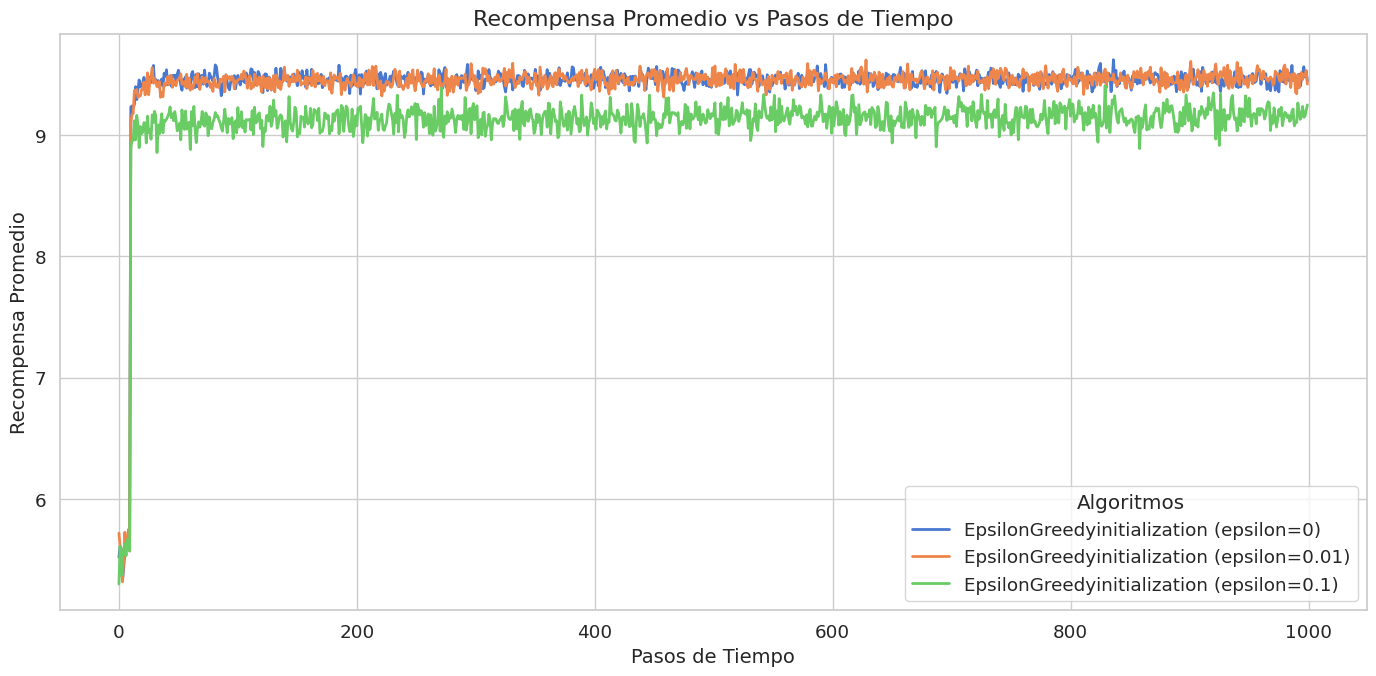

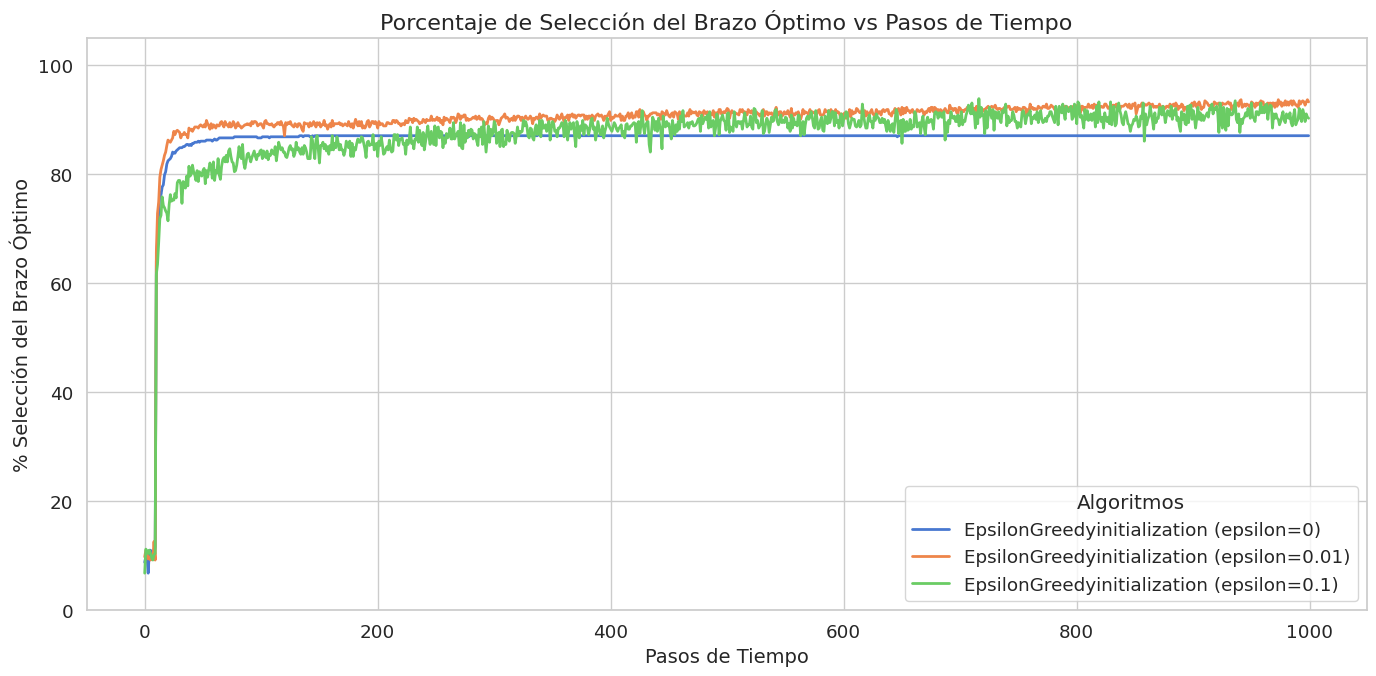

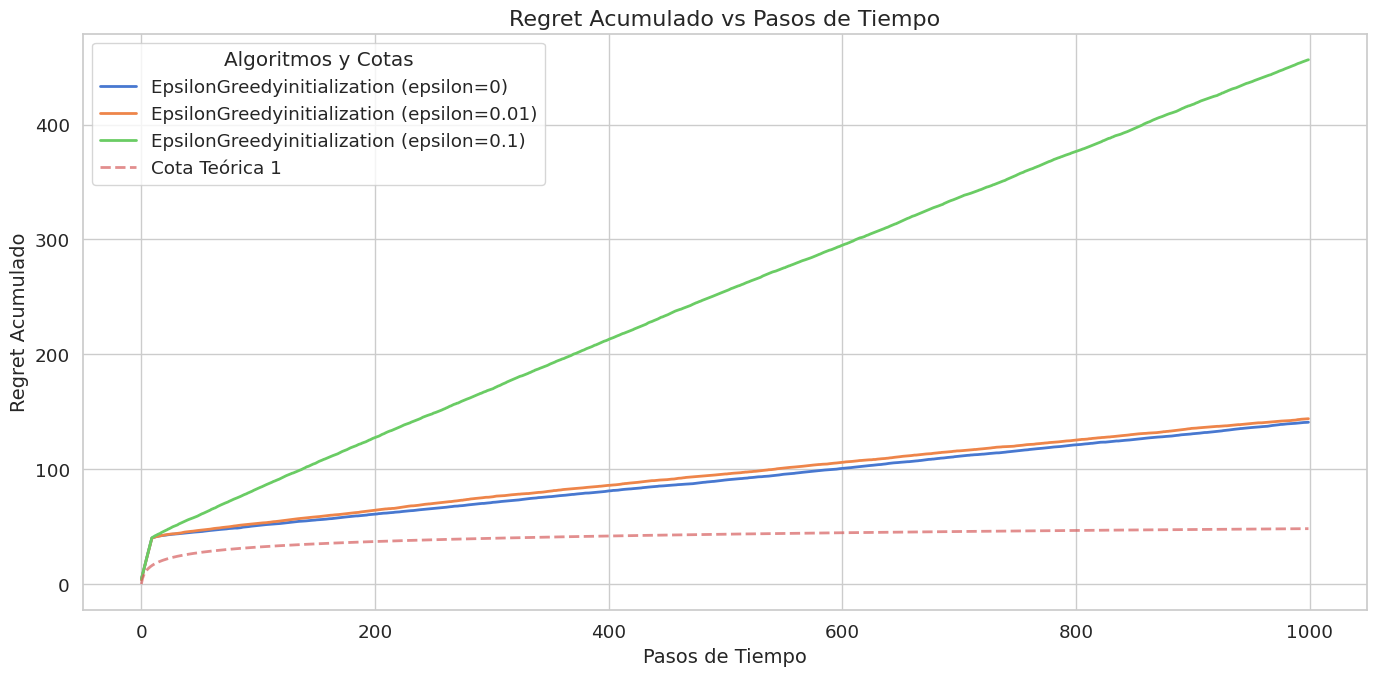

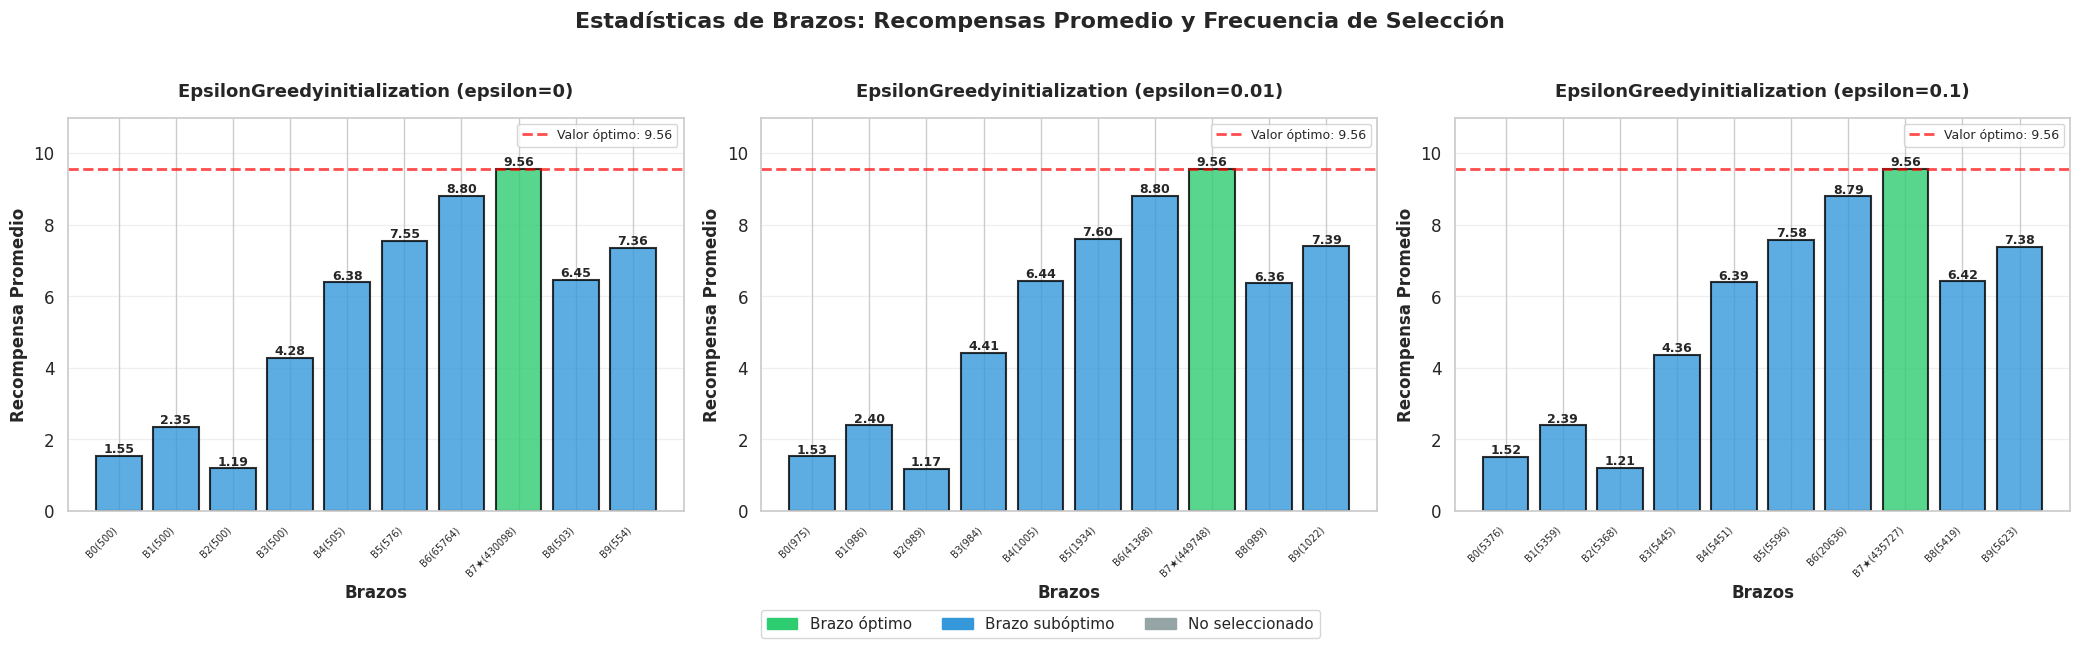

In [5]:

# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms)
plot_optimal_selections(steps, optimal_selections, algorithms)

# Cota teórica de Lai & Robbins calculada a partir de los parámetros del bandido
theoretical_bound = compute_theoretical_bound(bandit, steps)

plot_regret(steps, regret_accumulated, algorithms, theoretical_bound)
plot_arm_statistics(arm_stats, algorithms, optimal_arm)


### Análisis de resultados

La inicialización optimista fuerza una exploración sistemática de todos los brazos en los primeros pasos: como los valores iniciales están sobreestimados, cualquier recompensa real resultará decepcionante, lo que empuja al agente a seguir probando brazos en busca de uno que justifique la estimación inicial. Esto se traduce en una convergencia más rápida al brazo óptimo en comparación con la inicialización estándar, especialmente para valores de ε bajos o nulos.

### ¿Cuál de las gráficas es la más relevante y por qué?

La gráfica más relevante es la del **regret acumulado**, por el mismo motivo que en el experimento base: resume tanto la velocidad de aprendizaje como el coste total de exploración en una sola curva, y permite contrastar el rendimiento con la cota teórica de Lai & Robbins ($C \cdot \ln T$). En este experimento además resulta especialmente informativa para comparar si la inicialización optimista consigue un regret más bajo que la inicialización estándar: si la curva se acerca más a la cota teórica, la inicialización está siendo efectiva como mecanismo de exploración.

La gráfica de porcentaje de selecciones óptimas complementa bien este análisis, ya que muestra si la exploración forzada por la inicialización se traduce en una identificación más temprana del brazo óptimo.

## Conclusiones

La inicialización optimista actúa como un mecanismo de exploración implícito: al partir de estimaciones infladas, el agente se ve forzado a probar todos los brazos en los primeros pasos sin necesidad de un ε alto. Esto es especialmente útil cuando queremos que el agente explore al principio del entrenamiento pero converja rápidamente a la explotación, algo que el ε-greedy estándar solo logra con valores de ε moderados.

El efecto más notable se observa precisamente en ε=0: mientras que sin inicialización el greedy puro queda atrapado en el primer brazo que visita, con inicialización optimista acaba encontrando el brazo óptimo porque los valores sobreestimados lo obligan a explorar. La contrapartida es que este beneficio desaparece con el tiempo una vez que las estimaciones convergen, por lo que la inicialización optimista es un complemento, no un sustituto, a una política de exploración bien diseñada.